# 03_集成算法-投票法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿咱们来聊聊投票法\~

集成算法指的是把多个模型组合起来，让它们一起做决策。投票法就是其中一种常见的方法。

简单来说，每个模型就像一个专家，他们各自给出自己的判断，最后看哪个答案得到的票数最多，就把这个答案作为最终结果。

**硬投票：**每个模型只给出一个具体的类别，然后统计哪个类别的票数最多。比如，有三个模型分别预测某张图片是猫、狗、猫，票数最多的是猫，所以最终结果是猫。

**软投票**：每个模型给出的是属于每个类别的概率（信心值），然后把这些概率加起来，看哪个类别的总概率最高。比如，三个模型分别给出预测概率，通过计算得出哪个类别更可能，这样可以更细致地反映模型的信心。

当你不确定哪个模型最好时，可以用投票法把多个模型的优点结合起来，得到一个更可靠的预测结果。

## 原理详解

这里，我们主要讨论硬投票和软投票两种形式，以下内容假设有 $M$个基分类器（专家），目标是对输入样本 $x$进行分类，类别集合为 $\mathcal{C} = \{c_1, c_2, \dots, c_K\}$。

### 1. 数学原理与公式推导

#### 硬投票（Hard Voting）

每个基分类器 $h_i(x)$对样本 $x$给出一个确定的类别预测。最终输出类别由“多数表决”确定，也就是票数最多的类别。

对于每个分类器 $h_i(x)$，我们有预测结果 $h_i(x) \in \mathcal{C}$。定义指示函数：


$$
I(h_i(x) = c) =\begin{cases}1, & \text{若 } h_i(x)=c, \\0, & \text{否则.}\end{cases}
$$


最终预测类别 $\hat{y}$为：


$$
\hat{y} = \arg\max_{c \in \mathcal{C}} \sum_{i=1}^{M} I(h_i(x) = c)
$$


也就是说，对每个类别 $c$，统计所有模型中有多少个给出了 $c$的预测，选择票数最高的类别作为最终结果。

**理论推导：**

- 每个模型相当于从概率空间中取一个样本（即模型预测）。
- 假设各模型预测独立且准确率均大于随机猜测，多数投票能够放大正确预测的概率。
- 根据大数定律，当 $M$较大时，正确预测的模型数量更可能占多数，从而使得多数投票法具有降低单个模型误差的作用。

#### 软投票（Soft Voting）

每个基分类器不仅给出预测类别，还输出对每个类别的置信度（或概率），记为 $p_i(c|x)$，满足：


$$
\sum_{c \in \mathcal{C}} p_i(c|x) = 1.
$$


软投票法将各模型的概率值相加后，再选择概率总和最大的类别。

对于每个类别 $c$，计算总得分：


$$
S(c|x) = \sum_{i=1}^{M} p_i(c|x)
$$


最终预测类别 $\hat{y}$为：


$$
\hat{y} = \arg\max_{c \in \mathcal{C}} S(c|x)
$$


**加权软投票：**

若不同模型的重要性不同，可引入权重 $w_i$（满足 $\sum_{i=1}^{M} w_i = 1$或其他归一化形式）：


$$
S(c|x) = \sum_{i=1}^{M} w_i \, p_i(c|x)
$$


最终预测为：


$$
\hat{y} = \arg\max_{c \in \mathcal{C}} \sum_{i=1}^{M} w_i \, p_i(c|x)
$$


**理论推导：**

- 软投票法利用了模型输出的概率信息，使得模型之间的信息更为充分地结合。
- 当各个模型的概率分布较为可靠时，累加概率能够提供比单纯投票更精细的决策边界。
- 如果各个模型的输出满足良好的概率校准（calibration），那么加权求和可以近似于计算后验概率，从而达到贝叶斯最优决策的效果。

### 2. 算法流程

无论是硬投票还是软投票，其基本流程可以描述为：

#### 数据输入

- **输入样本：** 获取待分类的样本 $x$。
- **基分类器模型：** 已经训练好的 $M$个模型 $h_1, h_2, \dots, h_M$。

#### 模型预测

- **硬投票：**对每个模型 $h_i$，计算预测类别 $h_i(x)$。
- **软投票：**对每个模型 $h_i$，计算对每个类别的概率分布 $p_i(c|x)$。

#### 投票/概率累加

- **硬投票：**

  - 针对每个类别 $c \in \mathcal{C}$，计算票数：  
  $V(c) = \sum_{i=1}^{M} I(h_i(x)=c)$
  - 找出票数最大的类别：  
  $\hat{y} = \arg\max_{c \in \mathcal{C}} V(c)$
- **软投票：**

  - 针对每个类别 $c \in \mathcal{C}$，累加概率：  
  $S(c|x) = \sum_{i=1}^{M} p_i(c|x) \quad \text{（或加权后 } S(c|x) = \sum_{i=1}^{M} w_i \, p_i(c|x) \text{）}$
  - 选择概率总和最大的类别：  
  $\hat{y} = \arg\max_{c \in \mathcal{C}} S(c|x)$

#### 输出结果

- 输出最终预测的类别 $\hat{y}$。

### 3. 进一步的数学讨论

#### 鲁棒性分析

**错误互补性：**设每个模型出错的概率为 $\epsilon$（假设各模型误差相互独立），当 $M$增大时，根据二项分布，错误被“多数决”削弱的概率降低。这种思想可以用大数定律说明，即：


$$
P(\text{最终错误}) \approx \sum_{k > M/2} \binom{M}{k} \epsilon^k (1-\epsilon)^{M-k}
$$


当 $\epsilon < 0.5$且 $M$较大时，该概率迅速降低。

#### 加权投票的优化

- 当不同模型性能不同时，引入权重 $w_i$能够使得效果更优。权重通常与模型的准确率或者其他评价指标相关：  
$w_i \propto \text{accuracy}_i \quad \text{或} \quad w_i \propto \frac{1}{\text{error}_i}$
- 通过学习方法（如交叉验证）可以确定一组最优权重，从而在集成过程中更好地平衡各个模型的贡献。

总的来说，集成算法中的投票法利用多个基分类器的集体智慧来提高分类的准确性和稳定性。

硬投票直接对模型的离散预测进行计票，通过多数表决决策。软投票利用模型输出的概率信息进行累加，可以在一定程度上捕捉模型的置信度，甚至进一步通过加权来优化决策。

## 完整案例

咱们使用 Iris 数据集作为案例。

案例包含数据预处理、模型构建、模型评估、超参数优化以及决策边界的可视化。

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/

Logistic Regression Accuracy: 0.87 (+/- 0.08)
Decision Tree Accuracy: 0.94 (+/- 0.06)
KNN Accuracy: 0.96 (+/- 0.04)
Voting Accuracy: 0.95 (+/- 0.06)
Voting Classifier Test Accuracy: 0.9777777777777777


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/

Best Weights: [1, 1, 1]
Best Cross-Validated Accuracy: 0.9523809523809523
Optimized Voting Classifier Test Accuracy: 0.9777777777777777


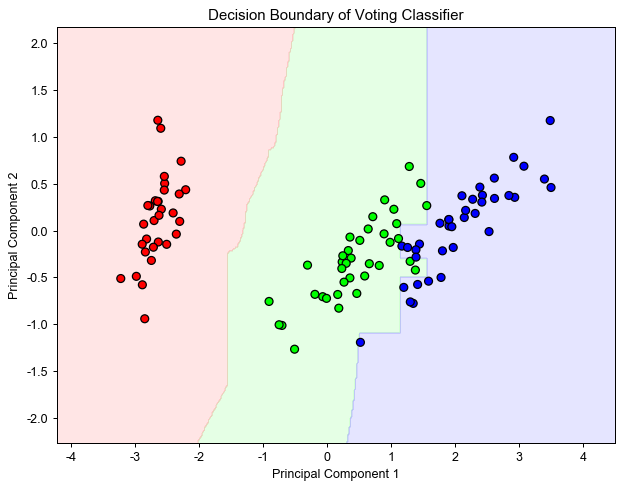

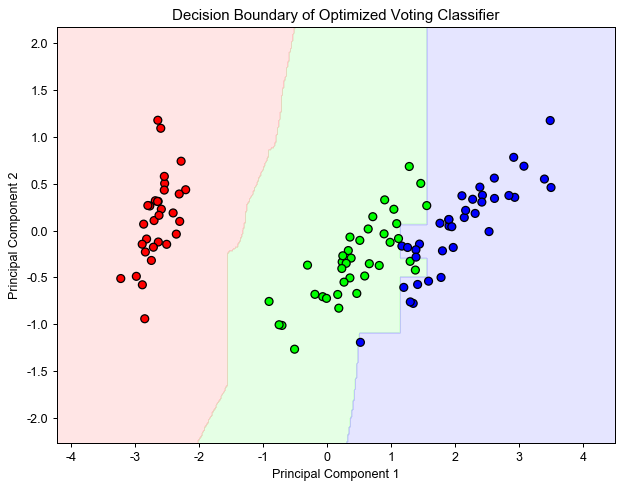

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from matplotlib.colors import ListedColormap

# 1. 数据加载与预处理
# 加载 Iris 数据集
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 使用 PCA 将数据降维到 2 维（便于可视化）
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=42)

# 2. 构建基本分类器与 Voting Classifier
# 定义三个基本分类器：逻辑回归、决策树、KNN
clf1 = LogisticRegression(random_state=42, solver='liblinear', multi_class='ovr')
clf2 = DecisionTreeClassifier(random_state=42)
clf3 = KNeighborsClassifier()

# 创建 VotingClassifier
# 初始设置为 soft voting, 利用各模型的概率信息
voting_clf = VotingClassifier(estimators=[
    ('lr', clf1),
    ('dt', clf2),
    ('knn', clf3)
], voting='soft')  # 可切换为 'hard' 进行硬投票

# 3. 模型训练与评估
# 分别在单个模型和投票集成上进行交叉验证
for clf, label in zip([clf1, clf2, clf3, voting_clf],
                      ['Logistic Regression', 'Decision Tree', 'KNN', 'Voting']):
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{label} Accuracy: {scores.mean():.2f} (+/- {scores.std():.2f})")

# 在测试集上训练并评估 VotingClassifier
voting_clf.fit(X_train, y_train)
print("Voting Classifier Test Accuracy:", voting_clf.score(X_test, y_test))

# 4. 超参数优化 - 优化各个分类器的权重
# 定义待调节的参数范围：为每个模型设置不同的权重组合
params = {
    'weights': [[w1, w2, w3] for w1 in range(1, 5)
                for w2 in range(1, 5)
                for w3 in range(1, 5)]
}

grid = GridSearchCV(estimator=voting_clf, param_grid=params, cv=5, scoring='accuracy', error_score='raise')
grid.fit(X_train, y_train)
print("Best Weights:", grid.best_params_['weights'])
print("Best Cross-Validated Accuracy:", grid.best_score_)

# 使用最佳权重重新构建 VotingClassifier，并评估测试集表现
voting_clf_opt = VotingClassifier(estimators=[
    ('lr', clf1),
    ('dt', clf2),
    ('knn', clf3)
], voting='soft', weights=grid.best_params_['weights'])
voting_clf_opt.fit(X_train, y_train)
print("Optimized Voting Classifier Test Accuracy:", voting_clf_opt.score(X_test, y_test))

# 5. 可视化决策边界
def plot_decision_boundary(clf, X, y, title):
    # 定义网格范围
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # 预测网格中的每个点
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 颜色映射
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolor='k', cmap=cmap_bold)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(title)
    plt.show()

# 可视化原始 VotingClassifier 的决策边界
plot_decision_boundary(voting_clf, X_train, y_train, "Decision Boundary of Voting Classifier")

# 可视化优化后 VotingClassifier 的决策边界
plot_decision_boundary(voting_clf_opt, X_train, y_train, "Decision Boundary of Optimized Voting Classifier")

1. **数据预处理**：利用 PCA 将原始 Iris 数据降至二维，便于可视化决策边界。划分训练集和测试集保证模型评估的可靠性。
2. **模型构建**：构造了三个基本分类器（逻辑回归、决策树和 KNN），并组合成 Voting Classifier。初始采用 soft voting 利用模型的概率信息。
3. **模型评估**：分别对单个模型和 Voting Classifier 进行交叉验证和测试集评估。通过交叉验证比较了各模型的表现，证明集成方法能提高准确性。
4. **超参数优化**：通过 GridSearchCV 对 Voting Classifier 的权重进行调优，从而优化集成模型的表现。通过调节不同的权重组合，找到最佳的模型融合方案。
5. **可视化决策边界**：利用 matplotlib 显示了不同类别的分布和模型决策边界。

![原文参考图，当前结果见代码输出](attachments/img_026.png)

## 模型分析

### 投票法模型的优缺点

**优点**：

- **简单直观**：投票法的原理非常容易理解，通过让多个基分类器各自“发言”，最后以多数票决定结果，逻辑清晰，易于实现。
- **模型互补**：不同的基分类器往往在各自的错误模式上存在差异，通过投票法可以充分发挥各模型的优势，降低单一模型偏差对最终结果的影响。
- **鲁棒性较强**：当基分类器之间的误差不完全相关时，多数决策能够有效抵消个别模型的偶然错误，从而提高整体预测的准确性。
- **灵活性高**：可以采用硬投票或软投票，同时通过权重调整进一步优化模型融合效果，满足不同场景的需求。

**缺点**：

- **依赖基模型性能**：如果所有基分类器的预测能力都较弱，则集成效果也难以提升，模型之间的错误共性可能导致多数投票失效。
- **调参复杂性**：在软投票中，为不同模型设定合适的权重往往需要大量的调参和验证工作，尤其在数据量较大时会增加计算开销。
- **不考虑模型间交互**：投票法简单地对各模型的预测结果进行统计或求和，没有进一步利用模型间可能存在的交互信息，这在某些复杂任务中可能不如其他更精细的集成方法（如 Boosting）有效。

### 与相似算法的对比

| **模型** | **优点** | **缺点** | **适用场景** |
|-|-|-|-|
| Voting Classifier (投票法) | - 实现简单、直观  <br/>- 充分利用多模型互补性  <br/>- 可通过硬投票或软投票灵活调节 | - 基于简单多数决策，不考虑模型间交互  <br/>- 对权重和基模型选择敏感  <br/>- 当所有基模型效果较弱时提升有限 | - 当多个效果各异但互补的模型可供组合  <br/>- 对模型组合要求简单、易实现且具有较好鲁棒性的场景 |
| Bagging | - 能够减少模型的方差  <br/>- 利用自助采样生成多个训练子集，降低过拟合风险  <br/>- 在基学习器稳定性不足时效果显著 | - 不能有效降低偏差  <br/>- 需要较多的基模型计算资源 | - 当基模型不稳定（例如决策树）且主要目标是降低方差  <br/>- 数据量充足且对训练时间要求不严格的场景 |
| Boosting | - 强调迭代训练，重点关注难以预测的样本  <br/>- 能够显著降低偏差并提升整体模型性能  <br/>- 集成的模型通常具有较高准确率 | - 对噪声和异常值较敏感  <br/>- 迭代过程中容易过拟合，调参较复杂  <br/>- 训练时间较长 | - 当需要进一步提升预测准确率，且对计算时间有一定容忍度  <br/>- 数据集较干净、噪声较少，适合对偏差敏感的问题 |

### 应用场景

当我们拥有多个表现较为均衡且互补的模型时，投票法能通过简单多数决策实现鲁棒性提升，尤其在数据噪声较多或各模型误差不完全相关的场景下，投票法可以更好地平衡各模型的优劣，降低整体风险。此外，对于初学者和工程实现要求简单的场景，投票法更容易上手和调试。

如果基模型之间存在较大偏差或需要对难以预测的样本进行重点处理时，Boosting 方法（如 AdaBoost 或 XGBoost）通常能更好地提升模型性能；而在需要大幅降低模型方差且基模型不稳定的情况下，Bagging（例如随机森林）可能更合适。

此外，在训练数据非常庞大或对实时性要求高的场景下，模型调参和训练时间也是重要考虑因素，可能需要选择计算复杂度更低或优化更好的算法。